# Making Carbonate Sensitivies for ROMS-MARBL-LiTE
This notebook demonstrates how to make the carbonate sensitivies `eta` and `beta`, needed to run `ROMS` with `MARBL-Lite` (see how to conduct a CDR release with `MARBL-LiTE` [here](https://roms-tools.readthedocs.io/en/latest/cdr_forcing.html#Using-CDR-releases-with-CDR-LiTE-(non-MARBL-BGC))). Rather than running the full biogeochemical model `MARBL`, `MARBL-LiTE` requires only a timeseries of the `eta` and `beta` fields. Where,
- ``eta  = dDIC / dALK``
- ``beta = dDIC / dCO2``

`eta` and `beta` can optionally be output from a previous run of `ROMS-MARBL`. Alternativley, we can calculate `eta` and `beta`, using `bgc` and `his` files from a previous run of `ROMS-MARBL`. We demonstrate the latter in this notebook. The variables collected from these files are `temp` and `salt` from the `his` files, and `ALK_ALT_CO2`, `DIC_ALT_CO2`, `salt`, `temp`, `PO4`, `SiO3` from the `bgc` files. 

**Note:** the frequency of output of your `bgc` and `his` records will determine how frequently your `eta` and `beta` fields are updated in a `ROMS-MARBL-LiTE` simulation. In this example we use daily. 

In [1]:
from roms_tools import Grid, calculate_eta_beta

Here we calculate `eta` and `beta` for a fjord in Icleand

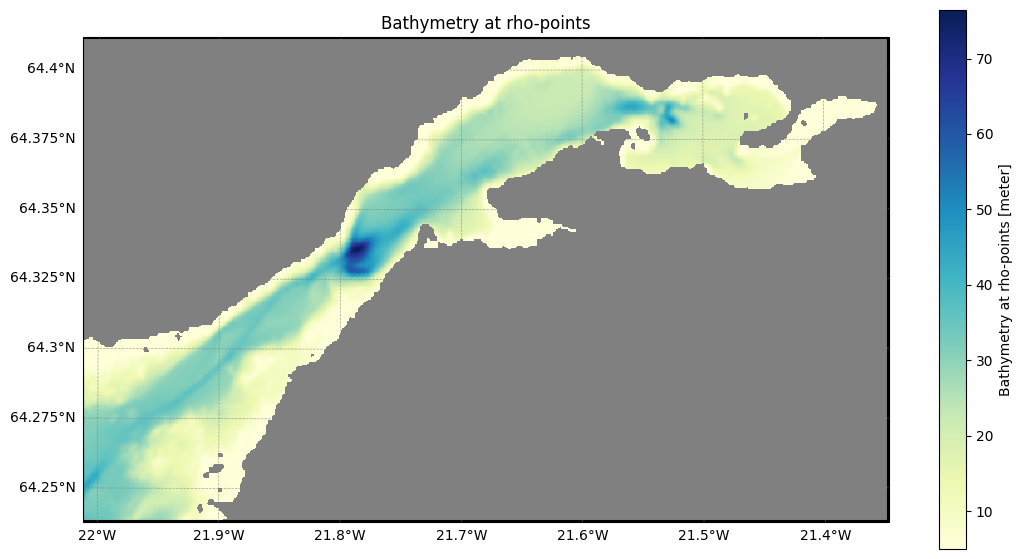

In [7]:
grid = Grid(filename="/Users/sam.maticka/workdir/CDR-Tracer-ROMS/files_testing/smaller/Iceland3_grid.nc")
grid.plot()

## Calculate `eta` and `beta`

Using an asterisk wildcard, we load in 9 daily files for each history and bgc files:

In [8]:
%%time 
fields = calculate_eta_beta(
    grid=grid,
    his_path="/Users/sam.maticka/workdir/CDR-Tracer-ROMS/files_testing/test_anvil/*his*",
    bgc_path="/Users/sam.maticka/workdir/CDR-Tracer-ROMS/files_testing/test_anvil/*bgc*",
)

2026-09-24 15:11:56 - INFO - Variables taken from his files: ['temp', 'salt', 'ocean_time']
2026-09-24 15:12:18 - INFO - Variables taken from bgc files: ['ALK_ALT_CO2', 'DIC_ALT_CO2', 'PO4', 'SiO3', 'ocean_time']


CPU times: user 47.2 s, sys: 27 s, total: 1min 14s
Wall time: 1min 18s


We can see the surface values that are extracted from the `his` and `bgc` files. These variables are used in the calculation of `eta` and `beta`:

In [9]:
fields.ds_surface_control

<xarray.Dataset> Size: 54MB
Dimensions:      (time: 9, eta_rho: 386, xi_rho: 642)
Dimensions without coordinates: time, eta_rho, xi_rho
Data variables:
    temp         (time, eta_rho, xi_rho) float32 9MB 11.17 11.17 ... -0.0 0.0
    salt         (time, eta_rho, xi_rho) float32 9MB 34.81 34.81 ... 0.0 0.0
    ocean_time   (time) float64 72B 7.74e+08 7.741e+08 ... 7.746e+08 7.747e+08
    ALK_ALT_CO2  (time, eta_rho, xi_rho) float32 9MB 2.302e+03 2.302e+03 ... 0.0
    DIC_ALT_CO2  (time, eta_rho, xi_rho) float32 9MB 2.081e+03 2.081e+03 ... 0.0
    PO4          (time, eta_rho, xi_rho) float32 9MB 0.6814 0.6817 ... 0.0 0.0
    SiO3         (time, eta_rho, xi_rho) float32 9MB 6.589 6.589 ... 0.0 0.0
Attributes: (12/46)
    global_x:           640
    global_y:           384
    title:                        Iceland3_MARBL_2024 , 50 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland3_MARBL_2024/P_INPUT/I...
    forcing_files:       /anvil/scratch/x-uheede/Iceland3_MARBL_2024/P_INPUT/...
    forcing_info:       
    ...                 ...
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        xxx
    type:               ROMS history file
    history:            Thu Sep 24 15:31:02 2026: ncks -O -d time,23,23 ../Ic...
    NCO:                netCDF Operators version 4.9.3 (Homepage = http://nco...

`eta` and `beta` are stored in a separate dataset `ds`:

In [10]:
fields.ds

<xarray.Dataset> Size: 40MB
Dimensions:     (time: 9, eta_rho: 386, xi_rho: 642)
Coordinates:
    lat_rho     (eta_rho, xi_rho) float64 2MB 64.24 64.24 64.24 ... 64.41 64.41
    lon_rho     (eta_rho, xi_rho) float64 2MB 338.0 338.0 338.0 ... 338.7 338.7
    ocean_time  (time) float64 72B 7.74e+08 7.741e+08 ... 7.746e+08 7.747e+08
    abs_time    (time) datetime64[ns] 72B 2024-07-11T11:00:00 ... 2024-07-19T...
Dimensions without coordinates: time, eta_rho, xi_rho
Data variables:
    eta         (time, eta_rho, xi_rho) float64 18MB 0.855 0.855 ... nan nan
    beta        (time, eta_rho, xi_rho) float64 18MB 12.65 12.64 ... nan nan

## Plotting sensitivity fields

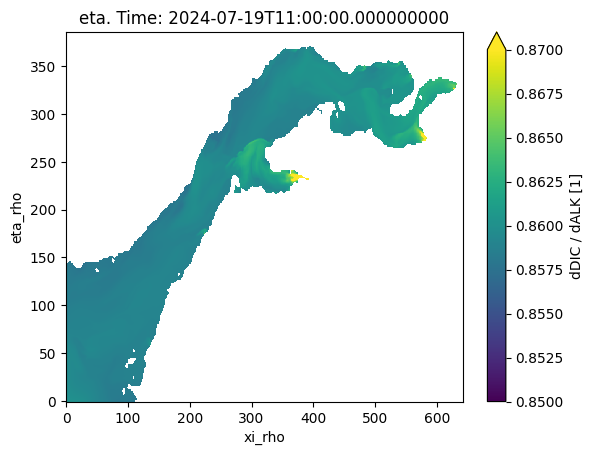

In [20]:
import matplotlib.pyplot as plt

tind=8

fields.ds.isel({"time":tind})["eta"].plot(vmin=0.85, vmax=0.87);
plt.title(f'eta. Time: {fields.ds["abs_time"].isel({"time":tind}).values}');

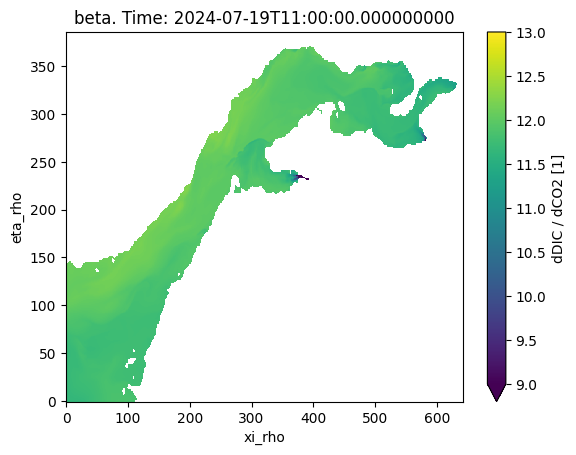

In [29]:
fields.ds.isel({"time":tind})["beta"].plot(vmin=9, vmax=13);
plt.title(f'beta. Time: {fields.ds["abs_time"].isel({"time":tind}).values}');